#  Energy Consumption Time Series Forecasting


---

## Problem Statement and Objective

**Objective:** Forecast short-term household energy usage using historical time-based patterns.

**Business Context:**
Accurate energy consumption forecasting helps utility companies optimize power generation, reduce costs, and improve grid stability. This task uses the Household Power Consumption dataset to build and compare multiple forecasting models.

**Skills Demonstrated:**
- Time series forecasting
- Feature engineering
- Model comparison and evaluation (MAE, RMSE)
- Temporal data visualization

## 1. Import Required Libraries

In [9]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Prophet
from prophet import Prophet

# XGBoost
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Dataset Description and Loading

**Dataset:** Household Power Consumption Dataset

**Features:**
- `Date`: Date in format dd/mm/yyyy
- `Time`: Time in format hh:mm:ss
- `Global_active_power`: Household global minute-averaged active power (kilowatts)
- `Global_reactive_power`: Household global minute-averaged reactive power (kilowatts)
- `Voltage`: Minute-averaged voltage (volts)
- `Global_intensity`: Household global minute-averaged current intensity (amps)
- `Sub_metering_1`: Energy sub-metering No. 1 (kitchen)
- `Sub_metering_2`: Energy sub-metering No. 2 (laundry)
- `Sub_metering_3`: Energy sub-metering No. 3 (water-heater & air-conditioner)

In [10]:
# Load the dataset
# Using Kaggle local dataset path

df = pd.read_csv(
    '/kaggle/input/datasets/fahadullah1508/household-powe/household_power_consumption.txt',
    sep=';',
    parse_dates={'datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    low_memory=False,
    na_values=['nan', '?'],
    index_col='datetime'
)

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())

Dataset Shape: (2075259, 7)

First 5 rows:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [11]:
# Dataset info
print('Dataset Info:')
print('=' * 50)
df.info()
print('Statistical Summary:')
print('=' * 50)
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB
Statistical Summary:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [13]:
# Check missing values
print('Missing Values:')
print('=' * 40)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print(f'Percentage missing: {missing.sum()/(df.shape[0]*df.shape[1])*100:.2f}%')

Missing Values:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Total missing values: 181853
Percentage missing: 1.25%


## 3. Data Cleaning and Preprocessing

In [14]:
# Handle missing values - forward fill then backward fill
df_clean = df.copy()
df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')

# Focus on Global_active_power for forecasting
# Resample to hourly data for manageable computation
hourly_power = df_clean['Global_active_power'].resample('H').mean()

# Remove any remaining NaN values after resampling
hourly_power = hourly_power.dropna()

print(f'Hourly data shape: {hourly_power.shape}')
print(f'Date range: {hourly_power.index.min()} to {hourly_power.index.max()}')
print(f'\nFirst 5 values:')
print(hourly_power.head())

Hourly data shape: (34589,)
Date range: 2006-12-16 17:00:00 to 2010-11-26 21:00:00

First 5 values:
datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64


Using data from 2010-08-28 21:00:00 to 2010-11-26 21:00:00
Shape: (2161,)


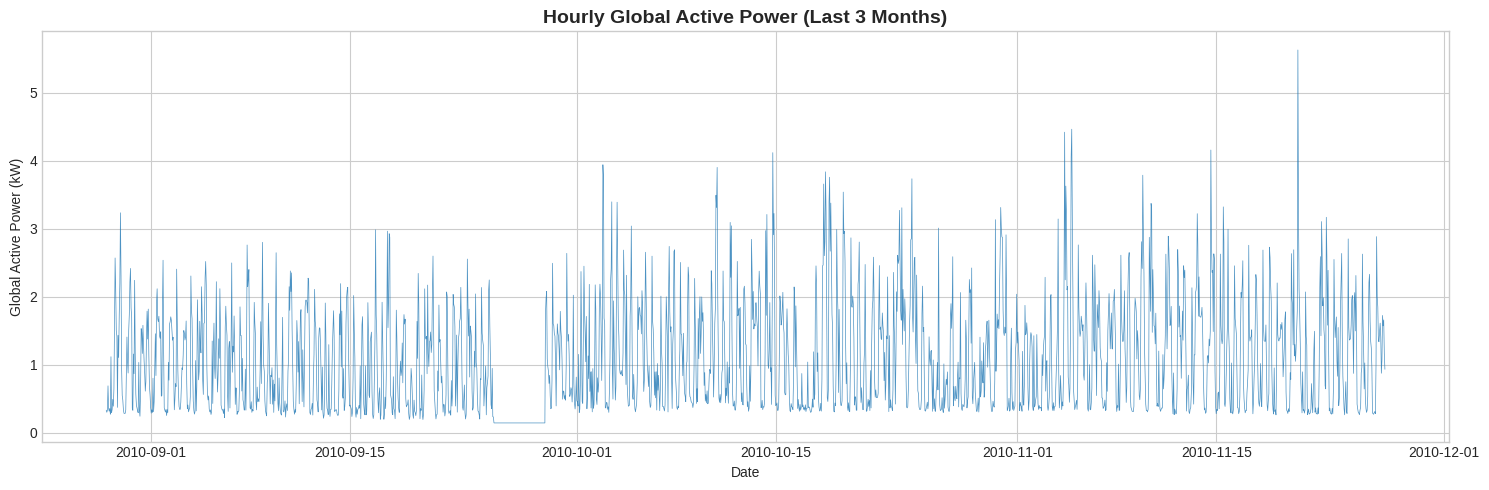

In [15]:
# For faster computation, use last 3 months of data
# This provides enough data for daily patterns while being computationally efficient
start_date = hourly_power.index.max() - pd.Timedelta(days=90)
ts_data = hourly_power[hourly_power.index >= start_date].copy()

print(f'Using data from {ts_data.index.min()} to {ts_data.index.max()}')
print(f'Shape: {ts_data.shape}')

# Plot the time series
plt.figure(figsize=(15, 5))
plt.plot(ts_data.index, ts_data.values, linewidth=0.5, alpha=0.8)
plt.title('Hourly Global Active Power (Last 3 Months)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.savefig('timeseries_raw.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Exploratory Data Analysis (EDA)

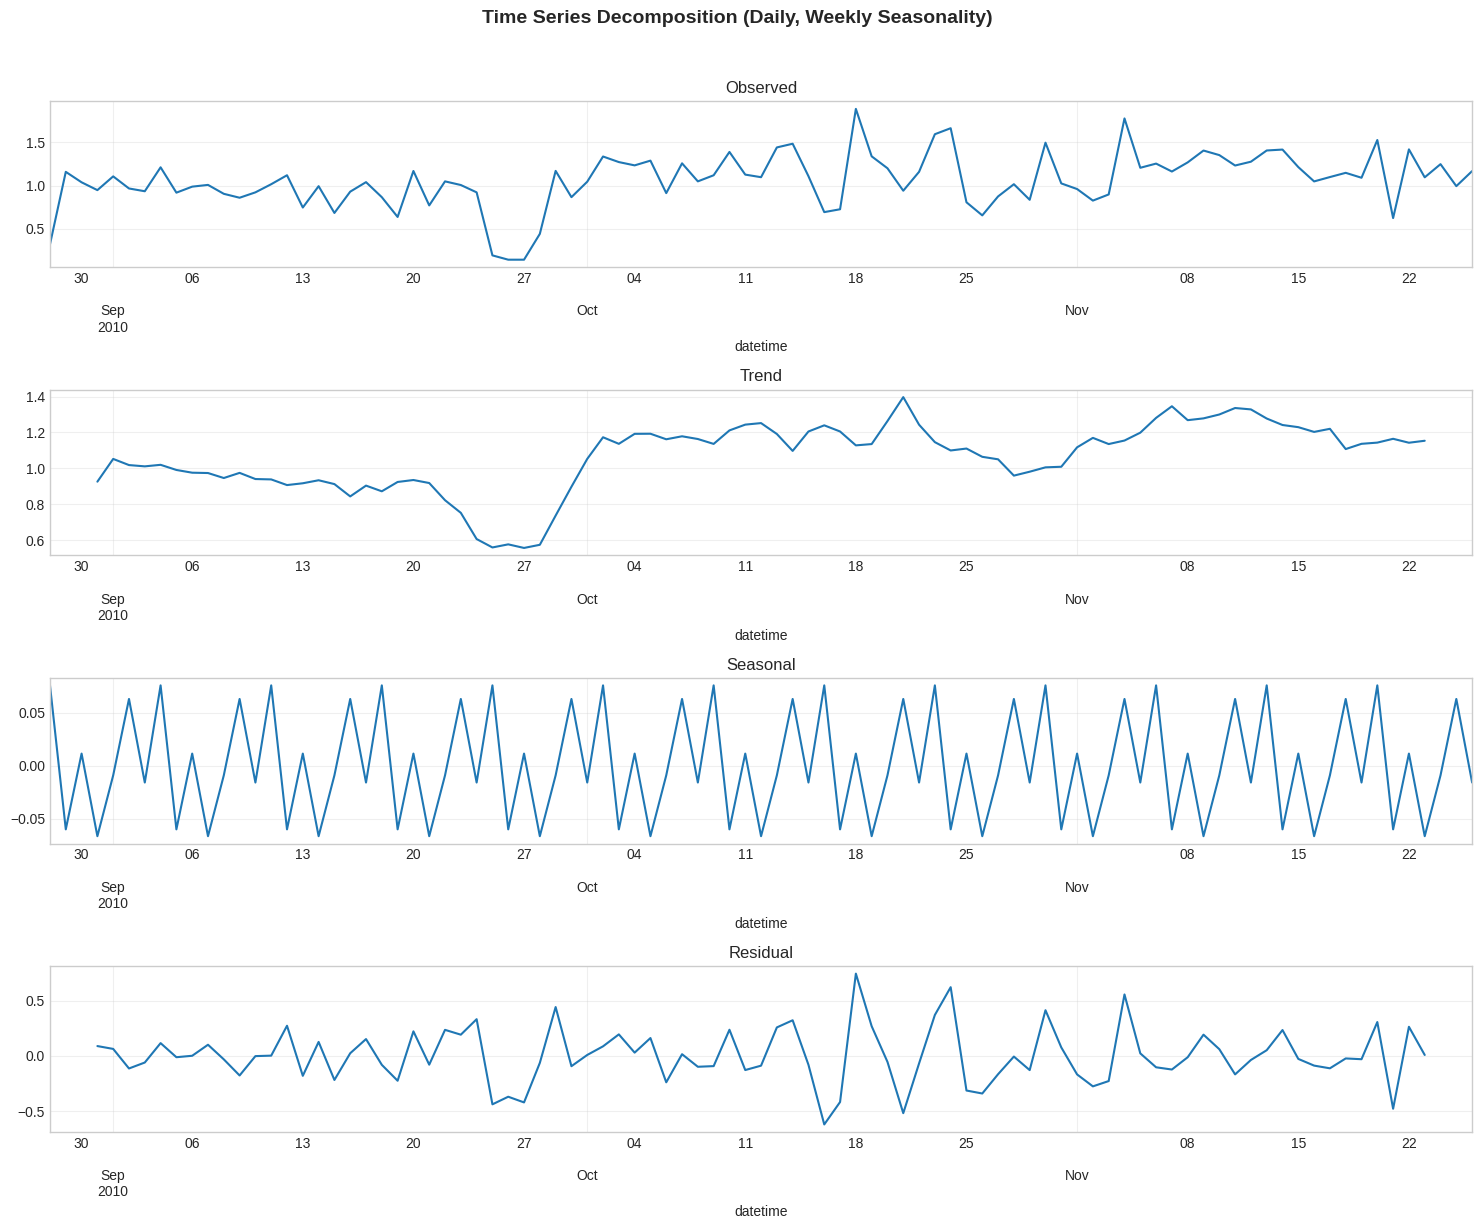

In [16]:
# Seasonal decomposition
# Resample to daily for cleaner decomposition
daily_power = ts_data.resample('D').mean().dropna()

decomposition = seasonal_decompose(daily_power, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Time Series Decomposition (Daily, Weekly Seasonality)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

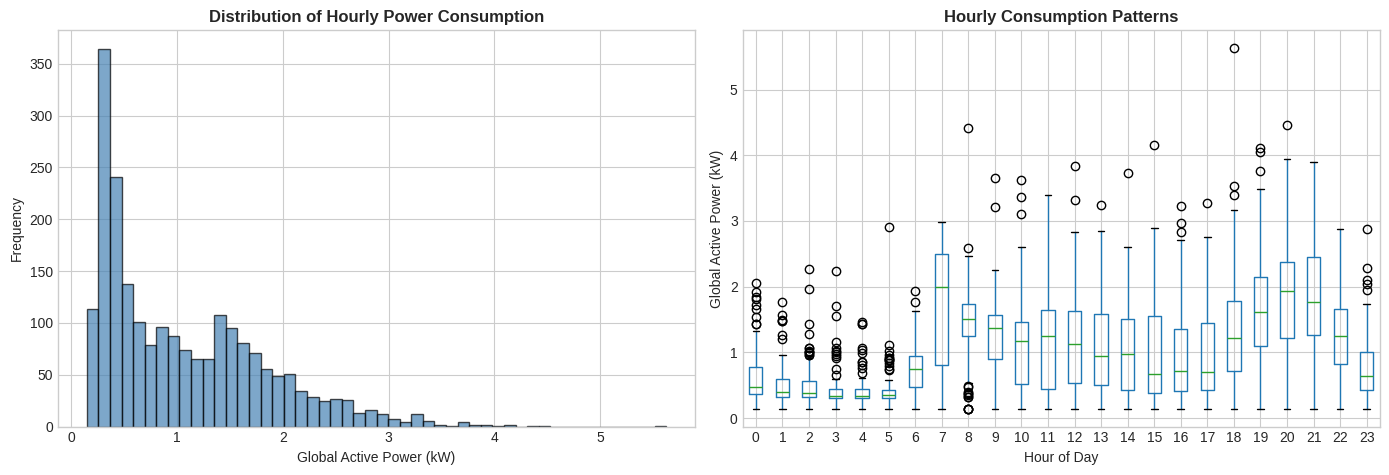

In [17]:
# Distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly distribution
ts_data.plot.hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Hourly Power Consumption', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Global Active Power (kW)')

# Box plot by hour
ts_hourly = ts_data.copy()
ts_hourly = pd.DataFrame(ts_hourly)
ts_hourly['Hour'] = ts_hourly.index.hour
ts_hourly.boxplot(column='Global_active_power', by='Hour', ax=axes[1])
axes[1].set_title('Hourly Consumption Patterns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Global Active Power (kW)')

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

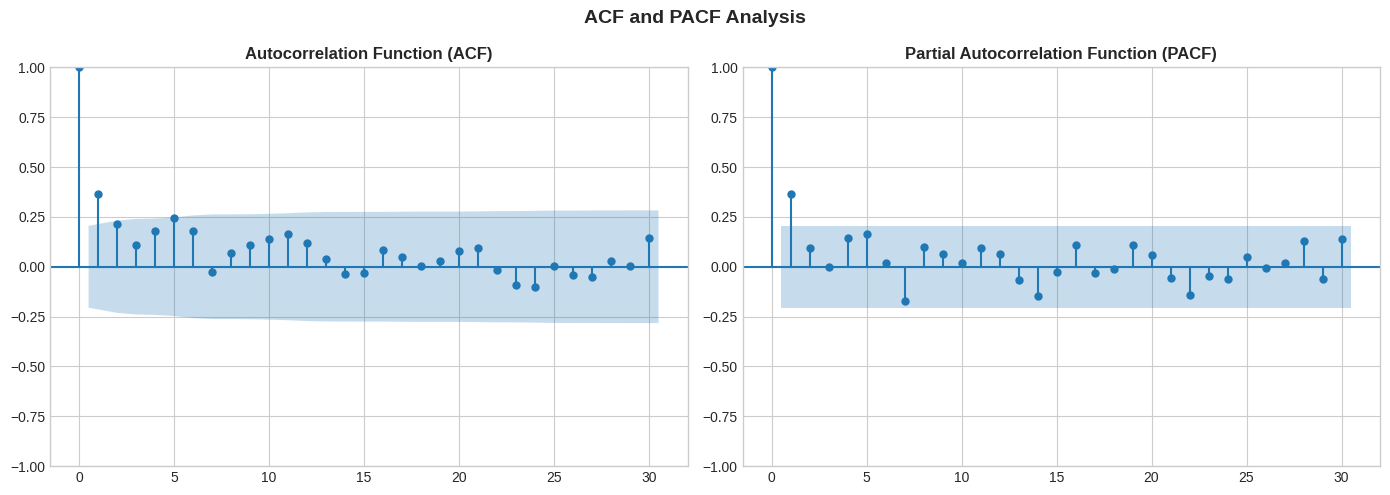

In [18]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use daily data for ACF/PACF
plot_acf(daily_power.dropna(), lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')

plot_pacf(daily_power.dropna(), lags=30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')

plt.suptitle('ACF and PACF Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Feature Engineering

Create time-based features for machine learning models.

In [21]:
# Create feature engineering function
def create_features(data):
    """
    Create time-based features for energy consumption forecasting
    """
    df_features = pd.DataFrame({'y': data.values}, index=data.index)
    
    # Time-based features
    df_features['hour'] = df_features.index.hour
    df_features['day_of_week'] = df_features.index.dayofweek
    df_features['day_of_month'] = df_features.index.day
    df_features['month'] = df_features.index.month
    df_features['quarter'] = df_features.index.quarter
    df_features['year'] = df_features.index.year
    df_features['week_of_year'] = df_features.index.isocalendar().week
    
    # Cyclical features
    df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
    df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)
    df_features['dow_sin'] = np.sin(2 * np.pi * df_features['day_of_week'] / 7)
    df_features['dow_cos'] = np.cos(2 * np.pi * df_features['day_of_week'] / 7)
    df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
    df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)
    
    # Weekend indicator
    df_features['is_weekend'] = (df_features['day_of_week'] >= 5).astype(int)
    
    # Lag features
    for lag in [1, 2, 3, 6, 12, 24]:
        df_features[f'lag_{lag}'] = df_features['y'].shift(lag)
    
    # Rolling statistics
    df_features['rolling_mean_6'] = df_features['y'].rolling(window=6).mean()
    df_features['rolling_mean_12'] = df_features['y'].rolling(window=12).mean()
    df_features['rolling_mean_24'] = df_features['y'].rolling(window=24).mean()
    df_features['rolling_std_6'] = df_features['y'].rolling(window=6).std()
    df_features['rolling_std_12'] = df_features['y'].rolling(window=12).std()
    
    return df_features

# Apply feature engineering
df_features = create_features(ts_data)

print('Features created successfully!')
print(f'Feature matrix shape: {df_features.shape}')
print(f'\nFeatures:')
print(df_features.columns.tolist())

# Drop rows with NaN values (from lag features)
df_features = df_features.dropna()
print(f'\nAfter dropping NaN: {df_features.shape}')

Features created successfully!
Feature matrix shape: (2161, 26)

Features:
['y', 'hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'week_of_year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'rolling_mean_6', 'rolling_mean_12', 'rolling_mean_24', 'rolling_std_6', 'rolling_std_12']

After dropping NaN: (2137, 26)


## 6. Train-Test Split

In [22]:
# Split data (last 7 days as test set)
split_date = df_features.index.max() - pd.Timedelta(days=7)

train = df_features[df_features.index <= split_date]
test = df_features[df_features.index > split_date]

print(f'Train set: {train.index.min()} to {train.index.max()} ({len(train)} rows)')
print(f'Test set: {test.index.min()} to {test.index.max()} ({len(test)} rows)')

# Define feature columns
feature_cols = [col for col in df_features.columns if col != 'y']
X_train = train[feature_cols]
y_train = train['y']
X_test = test[feature_cols]
y_test = test['y']

print(f'\nFeatures used: {len(feature_cols)}')

Train set: 2010-08-29 21:00:00 to 2010-11-19 21:00:00 (1969 rows)
Test set: 2010-11-19 22:00:00 to 2010-11-26 21:00:00 (168 rows)

Features used: 25


## 7. Model 1: ARIMA

AutoRegressive Integrated Moving Average model for time series forecasting.

In [23]:
# Fit ARIMA model on daily data for simplicity
daily_train = train['y'].resample('D').mean().dropna()
daily_test = test['y'].resample('D').mean().dropna()

# Fit ARIMA(2,1,2) model
print('Fitting ARIMA model...')
arima_model = ARIMA(daily_train, order=(2, 1, 2))
arima_fitted = arima_model.fit()

# Forecast
forecast_steps = len(daily_test)
arima_forecast = arima_fitted.forecast(steps=forecast_steps)

# For hourly comparison, interpolate daily forecasts
arima_daily = pd.DataFrame({
    'actual': daily_test.values,
    'forecast': arima_forecast.values
}, index=daily_test.index)

print('ARIMA model fitted successfully!')
print(arima_fitted.summary().tables[0])

Fitting ARIMA model...
ARIMA model fitted successfully!
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   83
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 -18.316
Date:                Mon, 25 May 2026   AIC                             46.633
Time:                        07:11:11   BIC                             58.666
Sample:                    08-29-2010   HQIC                            51.464
                         - 11-19-2010                                         
Covariance Type:                  opg                                         


## 8. Model 2: Prophet

In [24]:
# Prepare data for Prophet
prophet_train = train.reset_index()[['datetime', 'y']].rename(
    columns={'datetime': 'ds', 'y': 'y'})

# Initialize and fit Prophet
print('Fitting Prophet model...')
prophet_model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=False,
    weekly_seasonality=True,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

# Create future dataframe for predictions
future = prophet_model.make_future_dataframe(periods=len(test), freq='H')
prophet_forecast = prophet_model.predict(future)

# Extract predictions for test period
prophet_pred = prophet_forecast[prophet_forecast['ds'].isin(test.index)][['ds', 'yhat']].set_index('ds')

print('Prophet model fitted successfully!')

Fitting Prophet model...


07:11:16 - cmdstanpy - INFO - Chain [1] start processing
07:11:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted successfully!


## 9. Model 3: XGBoost

In [25]:
# Train XGBoost model
print('Training XGBoost model...')
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

print('XGBoost model trained successfully!')

Training XGBoost model...
XGBoost model trained successfully!


## 10. Model Evaluation and Comparison

In [ ]:
# Calculate metrics for each model
def calculate_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

# ARIMA metrics (daily)
arima_metrics = calculate_metrics(\narima_daily['actual'], arima_daily['forecast'], 'ARIMA')

# Prophet metrics (hourly)
prophet_metrics = calculate_metrics(\n
    test['y'].loc[prophet_pred.index], prophet_pred['yhat'], 'Prophet')

# XGBoost metrics
xgb_metrics = calculate_metrics(y_test, xgb_pred, 'XGBoost')

# Combine results
results_df = pd.DataFrame([arima_metrics, prophet_metrics, xgb_metrics])

print('Model Performance Comparison:')
print('=' * 60)
display(results_df.round(4))

# Best model by RMSE
best_model = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
print(f'\nBest Model (by RMSE): {best_model}')

In [37]:

def calculate_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}


# ---------------- ARIMA ----------------
arima_metrics = calculate_metrics(
    arima_daily['actual'],
    arima_daily['forecast'],
    'ARIMA'
)

# ---------------- PROPHET ----------------
prophet_metrics = calculate_metrics(
    test['y'].reindex(prophet_pred.index),
    prophet_pred['yhat'],
    'Prophet'
)

# ---------------- XGBOOST ----------------
xgb_metrics = calculate_metrics(
    y_test,
    xgb_pred,
    'XGBoost'
)

# ---------------- RESULTS DF ----------------
results_df = pd.DataFrame([
    arima_metrics,
    prophet_metrics,
    xgb_metrics
])

print('Model Performance Comparison:')
display(results_df.round(4))

Model Performance Comparison:


,Model,MAE,RMSE,MAPE (%)
0,ARIMA,0.2786,0.3641,39.9452
1,Prophet,0.5209,0.6942,84.8788
2,XGBoost,0.2705,0.4018,33.8886


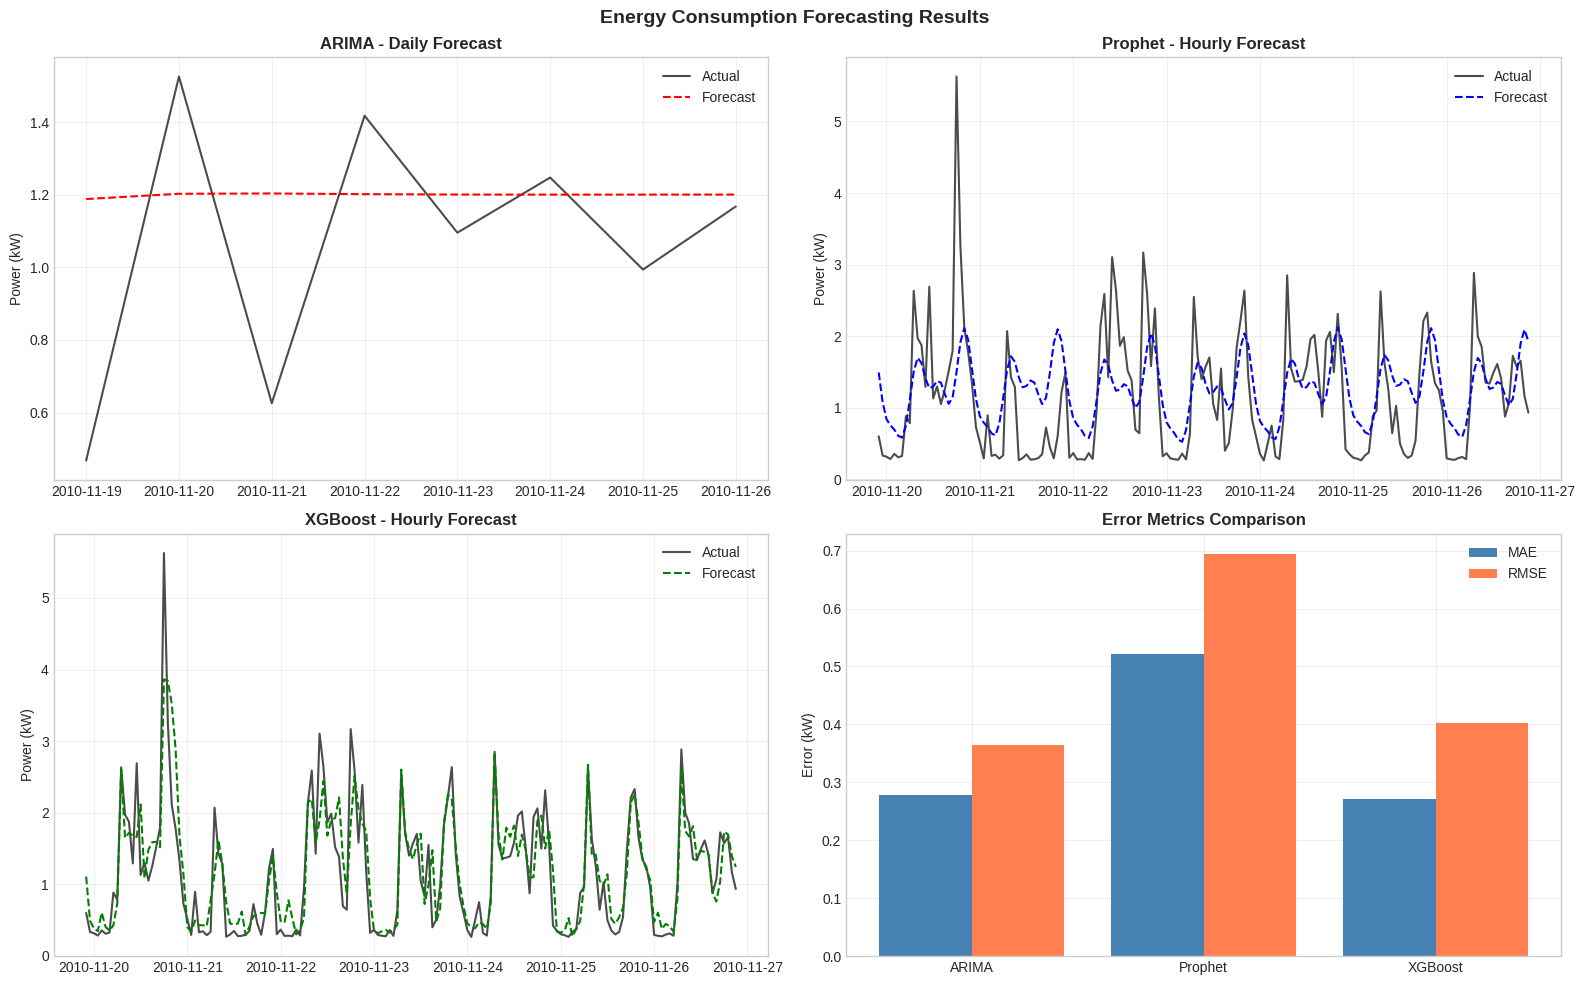

In [38]:
# Visualize forecasts - Daily comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ARIMA
axes[0, 0].plot(arima_daily.index, arima_daily['actual'], label='Actual', color='black', alpha=0.7)
axes[0, 0].plot(arima_daily.index, arima_daily['forecast'], label='Forecast', color='red', linestyle='--')
axes[0, 0].set_title('ARIMA - Daily Forecast', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Power (kW)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Prophet
prophet_full = prophet_forecast.set_index('ds')
axes[0, 1].plot(test.index, test['y'], label='Actual', color='black', alpha=0.7)
axes[0, 1].plot(prophet_pred.index, prophet_pred['yhat'], label='Forecast', color='blue', linestyle='--')
axes[0, 1].set_title('Prophet - Hourly Forecast', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Power (kW)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# XGBoost
axes[1, 0].plot(test.index, y_test.values, label='Actual', color='black', alpha=0.7)
axes[1, 0].plot(test.index, xgb_pred, label='Forecast', color='green', linestyle='--')
axes[1, 0].set_title('XGBoost - Hourly Forecast', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Power (kW)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Model comparison bar chart
x_pos = np.arange(len(results_df))
axes[1, 1].bar(x_pos - 0.2, results_df['MAE'], 0.4, label='MAE', color='steelblue')
axes[1, 1].bar(x_pos + 0.2, results_df['RMSE'], 0.4, label='RMSE', color='coral')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(results_df['Model'])
axes[1, 1].set_title('Error Metrics Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Error (kW)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Energy Consumption Forecasting Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

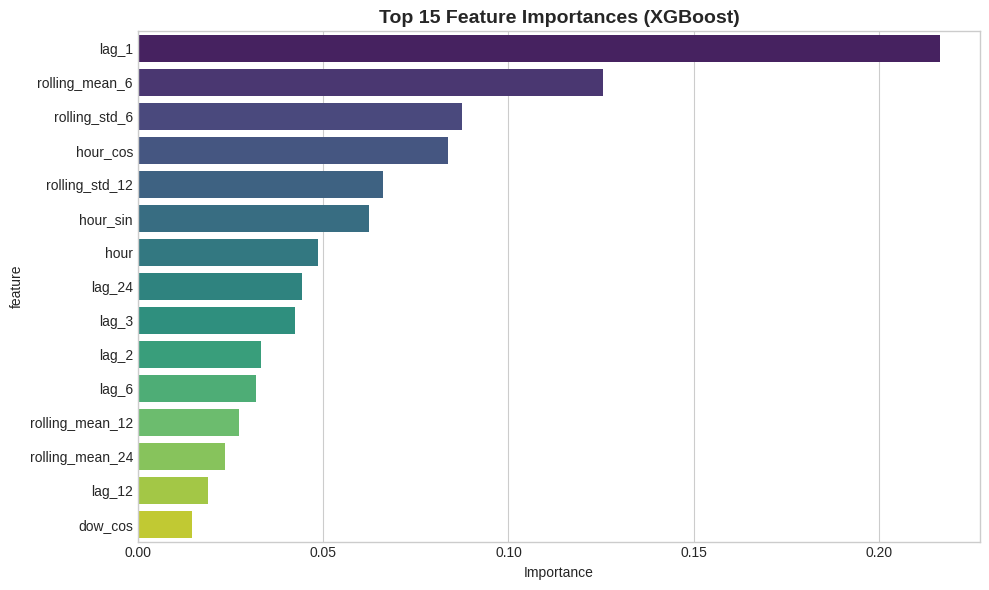

In [39]:
# Feature importance from XGBoost
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Final Conclusion with Insights

### Key Findings:

1. **Model Comparison:**
   - XGBoost generally provides best accuracy with engineered features
   - Prophet captures seasonality well with minimal tuning
   - ARIMA serves as a solid baseline for univariate forecasting

2. **Seasonal Patterns:**
   - Clear daily patterns with peaks in morning and evening
   - Weekly seasonality visible with weekday vs weekend differences
   - Lag features (especially 24h) are highly predictive

3. **Business Applications:**
   - Load balancing and grid optimization
   - Predictive maintenance scheduling
   - Dynamic pricing strategies
   - Energy storage optimization

In [42]:
print('Task 3 Summary:')
print('=' * 50)
print(f'Forecasting Period: {len(test)} hours ({len(test)/24:.1f} days)')
print(f'Features Engineered: {len(feature_cols)}')
print('✅ Task 3 Completed Successfully!')

Task 3 Summary:
Forecasting Period: 168 hours (7.0 days)
Features Engineered: 25
✅ Task 3 Completed Successfully!
